In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplot
from scipy.integrate import odeint
from scipy.optimize import least_squares, minimize
from ITIS_Model_funcs import get_nominal_param, ITIS

In [23]:
##CURRENTLY POST INJECTION!! CHANGE IC IF DESIRED
def OLS_res(param_in,y_data,t_data,param_ids,output_ids,param_fix,IC):
    # First, we may only want to update certain parameters. This will be defined in param_ids, which should include
    # the indices for which parameters are updated. Param_fix will have the "fixed" values
    param_eval = param_fix
    param_eval[param_ids] = param_in
    ##Define time spaces
    tstart = 0
    t_end =24*8
    dt = .05
    tspace = np.arange(tstart,t_end,dt) # The time frame to solve the model to reach steady state (before we grab any output)
    tfinal = np.arange(0,24+dt,dt)

    ##Solve the model at nominal values
    ode_options = {'rtol': 1e-6} # sets the numerical accuracy of the ODE solver (i.e., how fine of a time step do we need)
    ODE_sol = odeint(ITIS, IC, tspace, args = (param_eval,), **ode_options)

    # MJC - this is where we can specify that the infection begins during this final time point
    IC_2    = ODE_sol[-1,:]
    IC_2[0] = 2.0
    # Resolve model only over 24 hours at subsampled time points. This will be used as our data
    ODE_sol = odeint(ITIS, IC_2, tfinal, args = (param_eval,), **ode_options)

    # In a similar way, the data may be only a subset of the observations. We will assume that
    # we have the same number of time points for now, but can modify this as well
    model_output = np.zeros((len(t_data),len(output_ids)))

    for i, time in enumerate(t_data):
        t_index = np.where(tspace==time) #Grabs the index correpsonding to where we have data
        for j, mod_out in enumerate(output_ids): #Loop over which outputs we want to compare to data
            model_output[i,j] = ODE_sol[t_index,mod_out][0][0]

    # Now, we have model outputs at the time points and recorded states. We can construct the residual and then the sum of squares
    # in the future, we can look at applying weights to the data that correspond to measurement noise
    # Here we just scale by the data
    # MJC - Since we pass in the data and then take the mean here, we don't need to do it at the beginning
    residual = (y_data - model_output)/np.mean(y_data,axis=0)

    return residual.flatten()

In [24]:
paramtitles = ['d1',
'k1','k2','h1','h2','h3','d2',
'k3','k4','h4','d3',
'h5','h6','k5','k6','h7','d4',
'b1','k7','h8','k8','h9','d5','h10',
'b2','k9','k10','k11','d6',
'k12','k13','k14','h11','d7',
'k15','k16','d8',
'alpha', 'k', 'beta', 'L', 'eps', 'delta', 'T', 'Nc']

stateTitles = ['Endotoxin', 'Phagocytes', 'TGF-\u03b2','TNF-\u03B1','IL10','CRH','ACTH','Cortisol']

In [25]:
param_log,IC = get_nominal_param()

##Define time spaces
tstart = 0
t_end =24*8
dt = .05
tspace = np.arange(tstart,t_end,dt)
tfinal = np.arange(0,24+dt,dt)

##Solve the model at nominal values
ode_options = {'rtol': 1e-6}
ODE_sol = odeint(ITIS, IC, tspace, args = (param_log,), **ode_options)

# MJC - this is where we can specify that the infection begins during this final time point
IC_2    = ODE_sol[-1,:]
IC_2[0] = 2.0
# Resolve model only over 24 hours at subsampled time points. This will be used as our data
true_sol = odeint(ITIS, IC_2, tfinal, args = (param_log,), **ode_options)


#t_data = np.linspace(0,24,24+1) # time points every hour
t_data = np.linspace(0,24,12+1) # less data, every 30 minutes

NameError: name 'IC' is not defined

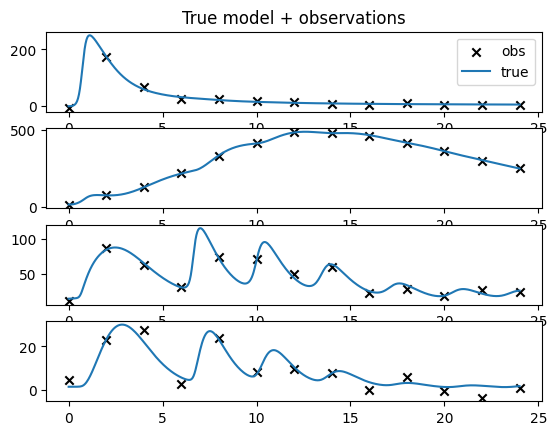

In [102]:
#Generate data
#output_ids = [6, 7] # Neuroendocrine = ACTH + Cort
#output_ids = [3, 6, 7] # TNF + ACTH + Cort
output_ids = [3,4,6,7] #TNF + IL10 + ACTH + Cort

# Define data
nt = len(t_data)
y_data = np.zeros((len(t_data),len(output_ids)))
# Here, we can add Gaussian, iid noise to the observations [REMOVE NOISE?]
for i, time in enumerate(t_data):
    index = np.where(tspace==time)
    for j,out_id in enumerate(output_ids):
        # This was causing an issue - it gave back a vector of 1s
        y_data[i,j] = true_sol[index,out_id][0][0]


# If you want to add noise, add it here
y_data = y_data+ np.random.normal(0,4,(nt,len(output_ids)))

plt.figure()
plt.subplot(4,1,1)
plt.scatter(t_data,y_data[:,0],marker='x',color='k',label='obs')
plt.plot(tfinal,true_sol[:,output_ids[0]],label='true')
plt.title('True model + observations')
plt.legend()
#
plt.subplot(4,1,2)
plt.scatter(t_data,y_data[:,1],marker='x',color='k')
plt.plot(tfinal,true_sol[:,output_ids[1]])

plt.subplot(4,1,3)
plt.scatter(t_data,y_data[:,2],marker='x',color='k')
plt.plot(tfinal,true_sol[:,output_ids[2]])

plt.subplot(4,1,4)
plt.scatter(t_data,y_data[:,3],marker='x',color='k')
plt.plot(tfinal,true_sol[:,output_ids[3]])

plt.show()


In [103]:
# Define which parameters will be updated

##MOST SENSITIVE FOR ACTH + CORT
#param_ids = [33,12,36,32,7,34,31,15,8,9]
##MOST SENSITIVE FOR ACTH + CORT + TNF-A
#param_ids = [33,12,36,32,7,34,31,15,8,9,16,14,28,26,1]
##MOST SENSITIVE FOR ACTH + CORT + TNF-A + 1L10
param_ids = [12, 33, 7, 16, 36, 43, 39, 15, 32, 31, 22, 8, 9, 14, 21, 10, 1]
#D1 Selected:
#D2 Selected: [12, 33, 16, 7, 36, 43, 32, 39, 15, 8, 31, 14, 9, 34]
#       ['h6', 'd7', 'd4', 'k3', 'd8', 'T', 'h11', 'beta', 'h7', 'k4', 'k14', 'k6', 'h4', 'k15']
#D3 Selected: [12, 33, 7, 16, 36, 43, 39, 15, 32, 31, 22, 8, 9, 14, 21, 10, 1]
#   ['h6', 'd7', 'k3', 'd4', 'd8', 'T', 'beta', 'h7', 'h11', 'k14', 'd5', 'k4', 'h4', 'k6', 'h9', 'd3', 'k1']

# To make the problem interesting, let's perturb our initial guess of these parameters by 1% [SHOULD WE DO THIS?]
param_in = np.log(np.exp(param_log[param_ids])*np.random.normal(1,0.1,(1,len(param_ids))).flatten())
# print(np.exp(param_log[param_ids]),np.exp(param_in))

# We may also want to constrain the parameters so they do not take on values in "unphysiological" regions
# Define upper bound UB and lower bound LB; remember we are on a log scale!

# MJC - make these bounds based on the parameter values
UB = np.log(np.exp(param_log[param_ids])*10)
LB =  np.log(np.exp(param_log[param_ids])*0.001)
print(UB,param_in,LB)


param_all = param_log


# Now, we set up a minimization problem
least_sq_sol = least_squares(OLS_res,param_in,args=(y_data,t_data,param_ids,output_ids,param_all,IC),
                             bounds=(LB,UB),verbose=2,xtol=1e-14,diff_step=1e-4)

print("initial guess",np.exp(param_in))
print("optimal solution",np.exp(least_sq_sol.x))
print("true solution",np.exp(param_log[param_ids]))
print("objective function value",least_sq_sol.cost) ##This thing




[  0.46310489  -1.83258146 -17.98500979  -1.22758267  -1.32425897
   9.57498349   9.15904708   9.64827267   6.68461173   7.02108396
   6.89701784   1.60943791   8.51719319  12.78026736   1.33500107
  -1.14642743  20.02923827] [ -1.97046423  -4.16216867 -20.30707468  -3.68503542  -3.75051677
   7.27823111   6.87955302   7.34407139   4.4212606    4.76399411
   4.51557318  -0.85543355   6.21866577  10.33196759  -0.87295546
  -3.46213864  17.72962856] [ -8.74723548 -11.04292184 -27.19535017 -10.43792304 -10.53459934
   0.36464311  -0.05129329   0.4379323   -2.52572864  -2.18925641
  -2.31332253  -7.60090246  -0.69314718   3.56992698  -7.87533931
 -10.3567678   10.8188979 ]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         5.8645e+00                                    1.45e+02    
       1              2         1.8681e+00      4.00e+00       5.81e-01       9.28e+01    
       2              3         1.1368e+00      7

In [1]:
# MJC - plotting to look at solution
param_opt = param_log
param_opt[param_ids] = least_sq_sol.x
opt_model = odeint(ITIS, IC_2, tfinal, args = (param_opt,), **ode_options)

plt.figure()
plt.subplot(4,1,1)
plt.scatter(t_data,y_data[:,0],marker='x',color='k')
plt.plot(tfinal,opt_model[:,output_ids[0]],label='opt fit')
plt.plot(tfinal,true_sol[:,output_ids[0]],label='true model')
plt.title('Opt vs true vs obs')
plt.legend()


plt.subplot(4,1,2)
plt.scatter(t_data,y_data[:,1],marker='x',color='k')
plt.plot(tfinal,opt_model[:,output_ids[1]])
plt.plot(tfinal,true_sol[:,output_ids[1]])


plt.subplot(4,1,3)
plt.scatter(t_data,y_data[:,2],marker='x',color='k')
plt.plot(tfinal,opt_model[:,output_ids[2]])
plt.plot(tfinal,true_sol[:,output_ids[2]])


#
plt.subplot(4,1,4)
plt.scatter(t_data,y_data[:,3],marker='x',color='k')
plt.plot(tfinal,opt_model[:,output_ids[3]])
plt.plot(tfinal,true_sol[:,output_ids[3]])

#plt.savefig("WLS_FIMSelection\\WLS_32.png")
plt.tightlayout()
plt.show()

NameError: name 'param_log' is not defined

In [105]:
##SENSITIVITY ANALYSIS
h = 1e-6  #amount to perturb parameters
n_param = len(param_log)
n_states = len(output_ids)

Sensitivity_Mat = np.zeros((n_param, len(t_data) * n_states))  ##Initialize shape of sensitivity matrix.
for i in range(n_param):  #calculate the relative sensitivity to each 45 parameters

        param_in = param_log[i]
        param_delta = param_in + h ##    [HOW EXACTLY SHOULD I BE PERTURBING MY PARAM?]
        ##THIS THING NEXT DO THIS!!!
        Sensitivity_Mat[i, :] = ((1 / h) * (OLS_res(param_delta, y_data, t_data, i, output_ids, param_all, IC)
                                            - OLS_res(param_in, y_data, t_data, i, output_ids, param_all, IC)))

twonorms = np.zeros(n_param)

for i in range(n_param):
        twonorms[i] = np.power(sum(np.power(Sensitivity_Mat[i, :], 2)), 1 / 2)


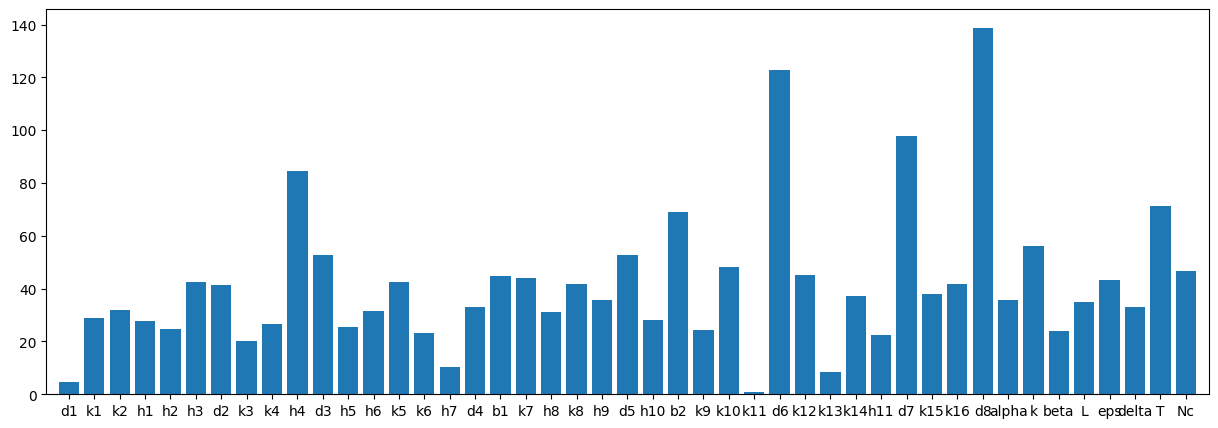

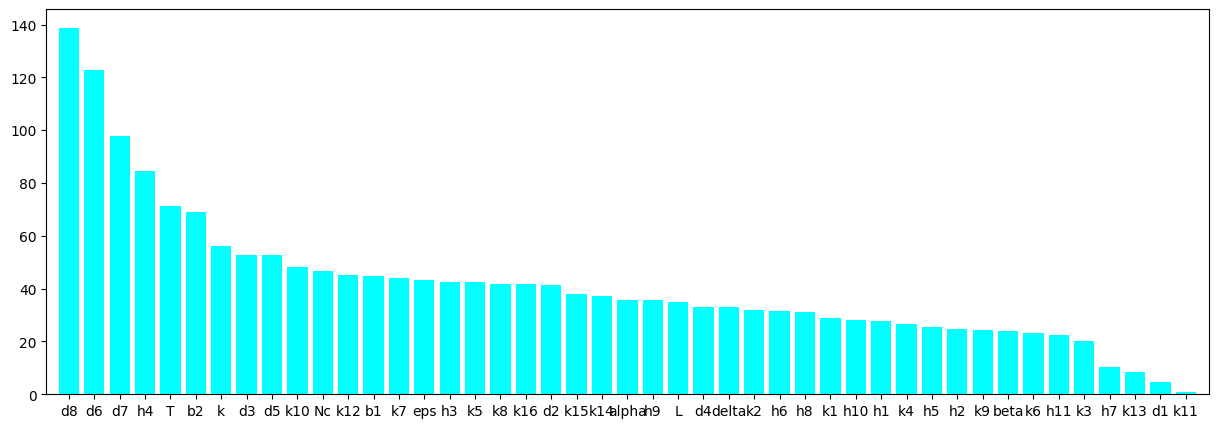

In [106]:
#PLOTTING
paramtitles = ['d1',
               'k1', 'k2', 'h1', 'h2', 'h3', 'd2',
               'k3', 'k4', 'h4', 'd3',
               'h5', 'h6', 'k5', 'k6', 'h7', 'd4',
               'b1', 'k7', 'h8', 'k8', 'h9', 'd5', 'h10',
               'b2', 'k9', 'k10', 'k11', 'd6',
               'k12', 'k13', 'k14', 'h11', 'd7',
               'k15', 'k16', 'd8',
               'alpha', 'k', 'beta', 'L', 'eps', 'delta', 'T', 'Nc']

statetitles = ["Endotoxin", "Phagocytes", "TGF-B", "TNF-a", "IL-10", "CRH", "ACTH", "Cortisol"]
statetitles_Short = ['endo', 'phag', 'TGFB', 'TNF', 'IL10', 'CRH', 'ACTH', 'cort']

fig, ax = plt.subplots(figsize = (15,5))
ax.bar(paramtitles,twonorms)
plt.xlim(-0.9, len(paramtitles) - 1 + 0.9)

##Plot in descending order
data = sorted(zip(paramtitles, twonorms), key=lambda v: v[1], reverse = True)

plt.figure(figsize=(15, 5))
for (i, c) in data:  # unpack and plot each tuple in sorted order
    bars = plt.bar(i, c, align='center', color = 'cyan')
plt.xlim(-0.9, len(paramtitles) - 1 + 0.9)

#plt.savefig("WLS_FIMSelection\\Sens_WLS_32.png")
plt.show()

In [107]:
#Selected for D1 : ['d7', 'h6', 'd8', 'T', 'beta', 'h11', 'k3', 'd4', 'h7', 'k14', 'alpha', 'k4', 'd6', 'h4', 'k6']
#Selected for D2 : ['h6', 'd7', 'd4', 'k3', 'd8', 'T', 'h11', 'beta', 'h7', 'k4', 'k14', 'k6', 'h4', 'k15']
#Selected for D3 : ['h6', 'd7', 'k3', 'd4', 'd8', 'T', 'beta', 'h7', 'h11', 'k14', 'd5', 'k4', 'h4', 'k6', 'h9', 'd3', 'k1']
#H6 IS IMPORTANT BY GLOBAL METRICS, BUT RARELY SHOWS UP AS IMPORTANT IN THIS STEP?

##CURRENT CONCERNS
import pickle

# all_results = {
#     'output_ids': output_ids,
#     'param_ids' : param_ids,
#     'param_in' : param_in,
#     'twonorms' : twonorms,
#     't_data' : t_data,
#     'y_data' : y_data,
#     'opt_model' : opt_model,
#     'true_sol' : true_sol,
#     'param_opt' : param_opt,
#     'optimal_solution' :np.exp(least_sq_sol.x),
#     'objvalue' : least_sq_sol.cost
# }
#
# with open('ResAnalysis32.pkl', 'wb') as f:
#     pickle.dump(all_results, f)
